In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load cleaned dataset
file_path = r"D:\Work - 2026\credit-risk-ml\data\processed\credit_default_clean.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# Basic overview
print("Rows and Columns:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

Rows and Columns: (30000, 24)

Column names:
 ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month']


In [4]:
# Data types and missing values
df.info()
print("\nMissing values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [5]:
# Summary statistics
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
# Target variable distribution
target_counts = df["default_payment_next_month"].value_counts()
target_percent = df["default_payment_next_month"].value_counts(normalize=True) * 100

print("Target counts:\n", target_counts)
print("\nTarget percentage:\n", target_percent)

Target counts:
 default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

Target percentage:
 default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


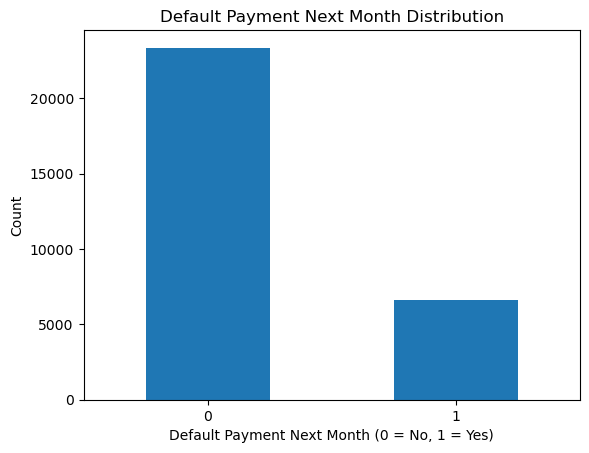

In [7]:
# Plot target class distribution
df["default_payment_next_month"].value_counts().sort_index().plot(kind="bar")
plt.title("Default Payment Next Month Distribution")
plt.xlabel("Default Payment Next Month (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

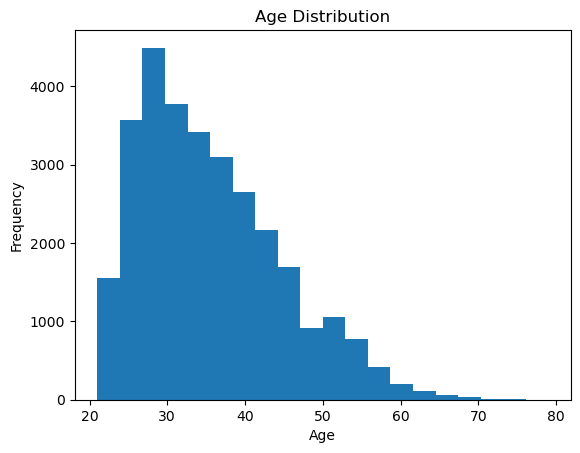

In [8]:
# Age distribution
df["AGE"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

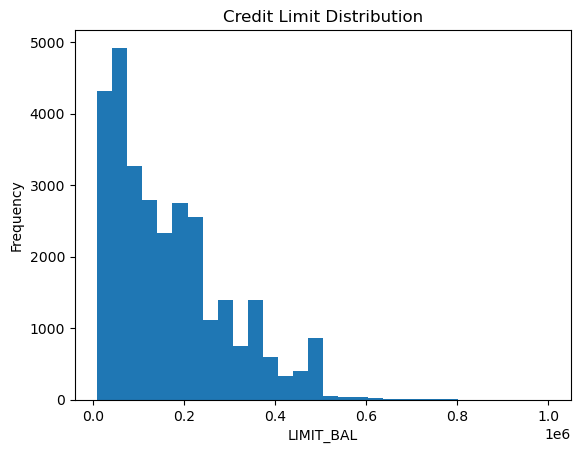

In [9]:
# Credit limit distribution
df["LIMIT_BAL"].plot(kind="hist", bins=30)
plt.title("Credit Limit Distribution")
plt.xlabel("LIMIT_BAL")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Average age by default status
print(df.groupby("default_payment_next_month")["AGE"].mean())

default_payment_next_month
0    35.417266
1    35.725738
Name: AGE, dtype: float64


SEX
1    11888
2    18112
Name: count, dtype: int64


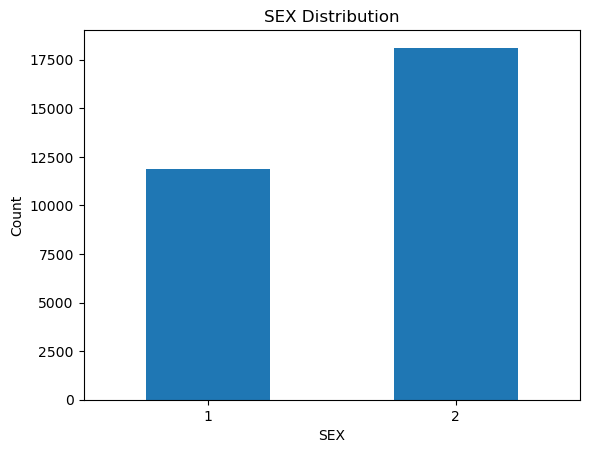

In [11]:
# SEX distribution
sex_counts = df["SEX"].value_counts().sort_index()
print(sex_counts)

sex_counts.plot(kind="bar")
plt.title("SEX Distribution")
plt.xlabel("SEX")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


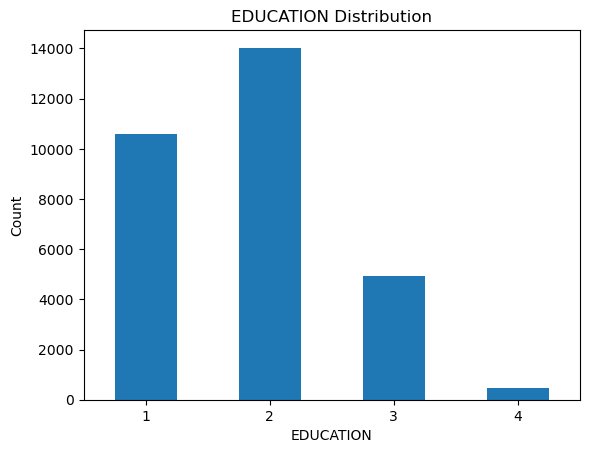

In [12]:
# EDUCATION distribution
education_counts = df["EDUCATION"].value_counts().sort_index()
print(education_counts)

education_counts.plot(kind="bar")
plt.title("EDUCATION Distribution")
plt.xlabel("EDUCATION")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


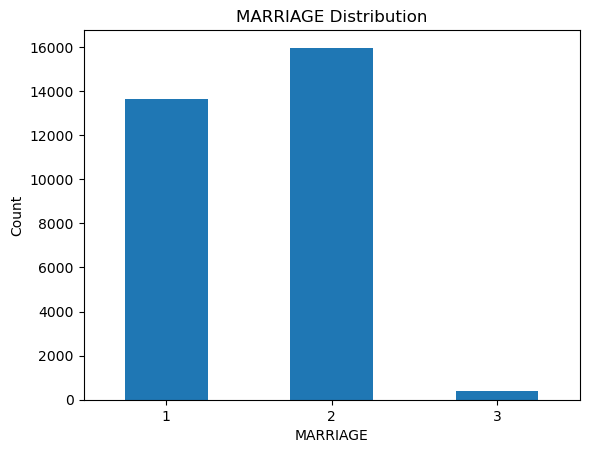

In [13]:
# MARRIAGE distribution
marriage_counts = df["MARRIAGE"].value_counts().sort_index()
print(marriage_counts)

marriage_counts.plot(kind="bar")
plt.title("MARRIAGE Distribution")
plt.xlabel("MARRIAGE")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [14]:
# Default rate by SEX
default_by_sex = pd.crosstab(df["SEX"], df["default_payment_next_month"], normalize="index") * 100
print(default_by_sex)

default_payment_next_month          0          1
SEX                                             
1                           75.832773  24.167227
2                           79.223719  20.776281


In [15]:
# Default rate by EDUCATION
default_by_education = pd.crosstab(df["EDUCATION"], df["default_payment_next_month"], normalize="index") * 100
print(default_by_education)

default_payment_next_month          0          1
EDUCATION                                       
1                           80.765234  19.234766
2                           76.265146  23.734854
3                           74.842384  25.157616
4                           92.948718   7.051282


In [16]:
# Default rate by MARRIAGE
default_by_marriage = pd.crosstab(df["MARRIAGE"], df["default_payment_next_month"], normalize="index") * 100
print(default_by_marriage)

default_payment_next_month          0          1
MARRIAGE                                        
1                           76.528296  23.471704
2                           79.071661  20.928339
3                           76.392573  23.607427


In [17]:
# Repayment status columns
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().sort_index())


Value counts for PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Value counts for PAY_2:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Value counts for PAY_3:
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

Value counts for PAY_4:
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

Value counts for PAY_5:
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

Value counts for PAY_6:
PAY_6
-2     4895
-1     5740
 0    16286


In [18]:
# Mean repayment status by default class
for col in pay_cols:
    print(f"\nAverage {col} by default status:")
    print(df.groupby("default_payment_next_month")[col].mean())


Average PAY_0 by default status:
default_payment_next_month
0   -0.211222
1    0.668174
Name: PAY_0, dtype: float64

Average PAY_2 by default status:
default_payment_next_month
0   -0.301917
1    0.458258
Name: PAY_2, dtype: float64

Average PAY_3 by default status:
default_payment_next_month
0   -0.316256
1    0.362116
Name: PAY_3, dtype: float64

Average PAY_4 by default status:
default_payment_next_month
0   -0.355633
1    0.254521
Name: PAY_4, dtype: float64

Average PAY_5 by default status:
default_payment_next_month
0   -0.389488
1    0.167872
Name: PAY_5, dtype: float64

Average PAY_6 by default status:
default_payment_next_month
0   -0.405624
1    0.112116
Name: PAY_6, dtype: float64


In [19]:
# Bill amount summary
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
df[bill_cols].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [20]:
# Payment amount summary
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
df[pay_amt_cols].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [21]:
# Correlation with target
correlation_with_target = df.corr(numeric_only=True)["default_payment_next_month"].sort_values(ascending=False)
print(correlation_with_target)

default_payment_next_month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.033842
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.027575
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default_payment_next_month, dtype: float64


In [22]:
# Top positive correlations
print("Top positive correlations with default:")
print(correlation_with_target.head(10))

Top positive correlations with default:
default_payment_next_month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.033842
AGE                           0.013890
BILL_AMT6                    -0.005372
Name: default_payment_next_month, dtype: float64


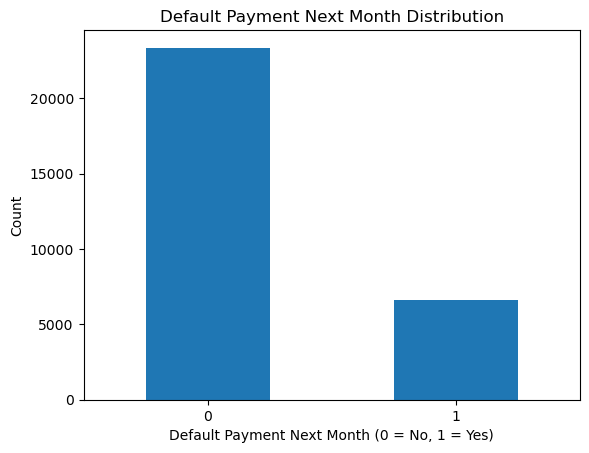

Figure saved at: D:\Work - 2026\credit-risk-ml\reports\figures\target_distribution.png


In [23]:
# Save target distribution figure
ax = df["default_payment_next_month"].value_counts().sort_index().plot(kind="bar")
plt.title("Default Payment Next Month Distribution")
plt.xlabel("Default Payment Next Month (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)

figure_path = r"D:\Work - 2026\credit-risk-ml\reports\figures\target_distribution.png"
plt.savefig(figure_path, bbox_inches="tight")
plt.show()

print(f"Figure saved at: {figure_path}")

In [24]:
print("EDA completed successfully.")
print("Dataset shape:", df.shape)
print("Target distribution:\n", df["default_payment_next_month"].value_counts(normalize=True))

EDA completed successfully.
Dataset shape: (30000, 24)
Target distribution:
 default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64
